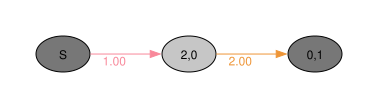

In [74]:
from phasic import Graph, StateIndexer, Property, with_ipv
import numpy as np                
import pandas as pd
from vscodenb import set_vscode_theme
set_vscode_theme()
from itertools import combinations_with_replacement

def get_ipv(self):
    ipv = np.zeros(self.vertices_length())
    for edge in self.starting_vertex().edges():
        ipv[edge.to().index()] = edge.weight()
    return ipv
           
def clone_with_ipv(self, ipv):
    """         
    clone but with new IPV. IPV must be an array/list of same length as number of graph vertices.
    """
    # ipv = _validate_ipv(ipv, allow_single_state=False)
    assert len(ipv) == self.vertices_length()
    assert ipv[self.starting_vertex().index()] == 0, "IPV cannot specify transition to itself"

    new = Graph(self.state_length())                                                              
    if self.parameterized():                                                                      
        new.set_param_length(self.param_length())
                                                                                                
    # vertices
    starting_vertex = self.starting_vertex()
    vmap = {starting_vertex.index(): new.starting_vertex()}                                   
    for v in self.vertices():
        if v.index() == starting_vertex.index():
            continue                                                                            
        vmap[v.index()] = new.create_vertex(list(v.state()))

    # IPV edges
    for i in range(self.vertices_length()):
        if ipv[i]:
            new.starting_vertex().add_edge(vmap[i], ipv[i])

    # remaining edges
    for v in self.vertices():                                                                     
        if not v.edges():
            assert ipv[v.index()] == 0, "IPV cannot specify transitions to absorbing states."
            continue
        if v.index() == starting_vertex.index():
            continue                                                                            
        nv = vmap[v.index()]
        if self.parameterized():
            for e in v.parameterized_edges():
                nv.add_edge(vmap[e.to().index()], list(e.edge_state(self.param_length())))
        else:
            for e in v.edges():                                                                 
                nv.add_edge(vmap[e.to().index()], e.weight())
                                                                                                
    new.is_discrete = self.is_discrete
    new._cache_trace = self._cache_trace
    new._trace = None                                                                           
    new._trace_dirty = True
    new._last_theta = None        
    new._joint_prob_base_graph_indexer = self._joint_prob_base_graph_indexer                                                              
    new._rewarded_props = self._rewarded_props    
    
    return new  


def joint_stop_prob_graph(self):  
    """
    Joint graph for computing joint probabilities across continuous time.
    """
    if not self._joint_prob_base_graph_indexer:
        raise ValueError("Graph is not a joint probability representation.")
                                                                                       
    new = Graph(self.state_length())                                                              
    if self.parameterized():                                                                      
        new.set_param_length(self.param_length())
                                                                                                
    start_old = self.starting_vertex()
    vmap = {start_old.index(): new.starting_vertex()}                                           

    def is_trash(v):
        if not v.state().sum() and v.edges_length() == 1:
            child = v.edges()[0].to()
            if not v.state().sum() and child.edges_length() == 1:
                return child.edges()[0].to().index() == v.index()
        return False

    t_vertex_indices = []
    trash_indices = []
    for v in self.vertices():
        if v.index() == start_old.index():
            continue
        if not v.edges():
            abs_index = v.index()  

        for edge in v.edges():
            if len(edge.to().edges()) == 0:
                t_vertex_indices.append(v.index())
                break

        if is_trash(v):
            trash_indices.append(v.index())
        vmap[v.index()] = new.create_vertex(list(v.state()))

    t_vertex_indices = np.unique(t_vertex_indices)
    assert len(trash_indices) == 2

    # t_vertex_indices = set(int(i) for i in t_vertex_indices) 
    # trash_indices = set(int(i) for i in trash_indices)

    t_aux_vertex_indices = dict()

    # add edges 
    for v in self.vertices():                                                                     
        if not v.edges():
            continue
        if v.index() in trash_indices:
            continue 

        nv = vmap[v.index()]

        if v.index() in t_vertex_indices:
            t_aux_vertex = new.create_vertex([0]*self.state_length())
            nv.add_edge(t_aux_vertex, [1]*self.param_length())
            t_aux_vertex.add_edge(nv, [1]*self.param_length())
            t_aux_vertex_indices[v.index()] = t_aux_vertex.index()
            continue

        for e in v.parameterized_edges():
            to_index = e.to().index()
            if to_index in trash_indices:
                to_index = abs_index
            if self.parameterized():
                nv.add_edge(vmap[to_index], list(e.edge_state(self.param_length())))
            else:
                nv.add_edge(vmap[to_index], e.weight())
                                                                                                
    new.is_discrete = self.is_discrete
    new._cache_trace = self._cache_trace
    new._trace = None                                                                           
    new._trace_dirty = True
    new._last_theta = None    
    new._joint_prob_base_graph_indexer = self._joint_prob_base_graph_indexer   
    new._rewarded_props = self._rewarded_props                                                           

    return new, t_aux_vertex_indices


def joint_stop_probabilities(self, t, t_aux_map):  
    """
    Joint prob graph IPV at time t. Made special so that t-states in the join graph are never left once entered.

    Should ONLY be used on graphs produced by joint_epoch_graph.
    """
    t_aux_indices = set(t_aux_map.values())
    all_stop_probs = self.stop_probability(t)
    stop_probs = []
    for i, p in enumerate(all_stop_probs):
        if i in t_aux_indices:
            continue
        if i in t_aux_map:
            p += all_stop_probs[t_aux_map[i]]
        stop_probs.append(p)

    return np.array(stop_probs)


def joint_probs_with_time(self, t, t_aux_map):  

    stop_probs = joint_stop_probabilities(self, t, t_aux_map)

    t_vertex_indices = np.array(sorted(t_aux_map.keys()))

    df = pd.DataFrame(self.states()[t_vertex_indices])
    df['probs'] = stop_probs[t_vertex_indices]
    return df


# def joint_graph_next_epoch_ipv(self, t):  

#     new, t_aux_vertex_indices = joint_epoch_graph(self)
#     return joint_graph_stop_probabilities(new, t, t_aux_vertex_indices)


# def joint_probs_final_epoch(self, t=100):  

#     new, t_aux_map = joint_epoch_graph(self)

#     return joint_probs_with_time(new, t, t_aux_map)



N_SAMPLES = 2
EPOCH_BOUNDARY = 0.3
# EPOCH_BOUNDARY = 10
TRUE_THETA1 = 2
TRUE_THETA2 = 0.5
# MUTATION_RATE = 0.01
MUTATION_RATE = 1
REWARD_LIMIT = 2      # cap on mutations per locus the joint graph tracks

def coal_callback(state, indexer=None):
    transitions = []
    for i, j in combinations_with_replacement(range(indexer.lineages.state_length), 2):
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        new[min(i + j + 1, state.size - 1)] += 1
        pair_count = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, [pair_count]])
    return transitions

# base graph indexer
indexer = StateIndexer(
    lineages=[Property('descendants', min_value=1, max_value=N_SAMPLES)],
)
# base graph ipv
ipv = [0] * indexer.state_length
ipv[indexer.lineages.props_to_index(descendants=1)] = N_SAMPLES 

graph = Graph(coal_callback, ipv=ipv, indexer=indexer)
graph.update_weights([TRUE_THETA1])
graph.plot()

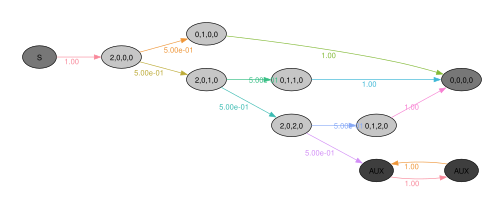

In [75]:
joint_graph = graph.joint_prob_graph(mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT) 
joint_graph.update_weights([TRUE_THETA1, 1])
joint_graph.plot(nodesep=0.5)

In [76]:
df = joint_graph.joint_prob_table()
print(f'Deficit: {1 - df.prob.sum():.4g}')
df

Deficit: 0.125


,descendants_1,descendants_2,prob
t_vertex_index,,,
2,0,0,0.500
4,1,0,0.250
6,2,0,0.125


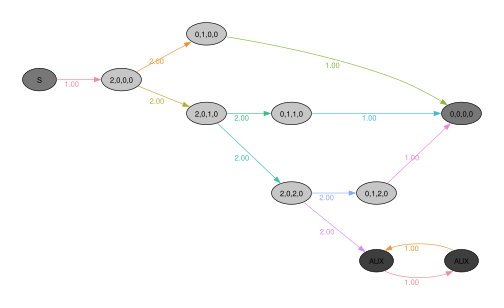

In [77]:
joint_graph_cont = graph.joint_prob_graph(mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT, discrete=False) 
joint_graph_cont.update_weights([TRUE_THETA1, 1])
joint_graph_cont.plot()

In [78]:
df = joint_graph_cont.joint_prob_table()
print(f'Deficit: {1 - df.prob.sum():.4g}')
df

Deficit: 0.125


,descendants_1,descendants_2,prob
t_vertex_index,,,
2,0,0,0.500
4,1,0,0.250
6,2,0,0.125


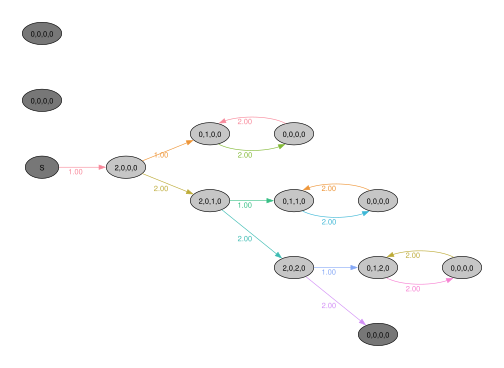

In [79]:
g, tmap = joint_stop_prob_graph(joint_graph_cont)
g.plot()

In [80]:
# MAKE JOINT_PROB_TABLE CALL THIS FUNCTION IF THE JOINT GRAPH IS CONTINUOUS
joint_probs_with_time(g, EPOCH_BOUNDARY, tmap)

,0,1,2,3,probs
0,0,1,0,0,0.198306
1,0,1,1,0,0.050738
2,0,1,2,0,0.009330


In [81]:
joint_probs_with_time(g, 100, tmap)

,0,1,2,3,probs
0,0,1,0,0,0.333333
1,0,1,1,0,0.222222
2,0,1,2,0,0.148148


## Full example of computing the joint probability table for a multi-epoch model

Sanity check: 200 epochs of alternating thetas should produce the same joint probabilities as the time-homogeneous single epoch model.

In [138]:
# base graph
graph = Graph(coal_callback, ipv=ipv, indexer=indexer)
graph.update_weights([TRUE_THETA1])   

# continuous joint prob graph
joint_graph = graph.joint_prob_graph(mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT, discrete=False) 

epoch_ipv = get_ipv(joint_graph)

# alternating between two coal rates
theta1, theta2 = 3, 5
# corresponds to constant 
mean_theta = 2 / (1 / theta1 + 1 / theta2)
mean_theta = (theta1 + theta2) / 2

n_epochs = 200
assert not n_epochs % 2
epoch_starts = np.linspace(0, 3, num=n_epochs)
epoch_theta = [[theta1, 1], [theta2, 1]] * int(n_epochs / 2)
epoch_ipv = get_ipv(joint_graph)

for i in range(len(epoch_starts)-1):

    # clone the continuous joint prob graph with the ipv from prev epoch
    joint_graph_with_epoch_ipv = clone_with_ipv(joint_graph, epoch_ipv)

    # # update weights
    # joint_graph_with_epoch_ipv.update_weights(epoch_theta[i])

    # get graph for computing joint prob stop probs
    jsp_graph, t_map = joint_stop_prob_graph(joint_graph_with_epoch_ipv)

    # update weights
    jsp_graph.update_weights(epoch_theta[i])

    # get ipv for start of next epoch
    epoch_ipv = joint_stop_probabilities(jsp_graph, epoch_starts[i+1], t_map)
    # with np.printoptions(precision=4, suppress=True):
    #     print(epoch_ipv)

# clone the continuous joint prob graph with the ipv from prev epoch
joint_graph_with_epoch_ipv = clone_with_ipv(joint_graph, epoch_ipv)

# update weights
joint_graph_with_epoch_ipv.update_weights(epoch_theta[-1]) 

# get graph for computing joint prob stop probs
jsp_graph, t_map = joint_stop_prob_graph(joint_graph_with_epoch_ipv)


epoch_ipv = joint_stop_probabilities(jsp_graph, epoch_starts[-1], t_map)
# with np.printoptions(precision=4, suppress=True):
#     print(epoch_ipv)

# get joint probs for final epoch
joint_probs_with_time(jsp_graph, 1, t_map) # FIXME: automate default high t to get probs to converge


,0,1,2,3,probs
0,0,1,0,0,0.664991
1,0,1,1,0,0.223294
2,0,1,2,0,0.074467


Single epoch with mean theta:

In [139]:
joint_graph = graph.joint_prob_graph(mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT) 
joint_graph.update_weights([mean_theta, 1]) 
joint_graph.joint_prob_table()

,descendants_1,descendants_2,prob
t_vertex_index,,,
2,0,0,0.666667
4,1,0,0.222222
6,2,0,0.074074


In [129]:
theta1, theta2 = 2, 3
harmonic_mean = 2 / (1 / theta1 + 1 / theta2)

In [9]:
t_vertex_indices = []
for vertex in joint_graph_cont.vertices():
    for edge in vertex.edges():
        if len(edge.to().edges()) == 0:
            t_vertex_indices.append(vertex.index())
            break
t_vertex_indices = np.unique(t_vertex_indices)
t_vertex_indices

joint_graph_epoch_ipv(joint_graph_cont, t=100)[t_vertex_indices]

array([0.33333333, 0.22222222, 0.14814815])

In [ ]:
# base graph
graph = Graph(coal_callback, ipv=ipv, indexer=indexer)
graph.update_weights([TRUE_THETA1])   

# continuous joint prob graph
joint_graph = graph.joint_prob_graph(mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT, discrete=False) 

epoch_ipv = get_ipv(joint_graph)

for i in range(len(epoch_starts)-1):
    
    joint_graph_epoch = clone_with_ipv(joint_graph, epoch_ipv)
    joint_graph_epoch.update_weights(epoch_theta[i]) # TO NOT HAVE TO DO THE ELIMINATION FOR EACH EPOCH IT WOULD BE GREAT IF I
                                                     # COULD INCLUDE THE IPV IN THE UPDATE SOMEHOW...
                                                     # BUT THAT WOULD REQUIRE THAT THE IPV BECOMES PARAMETERIZED IN THE 
                                                     # TRACE SOMEHOW.

    epoch_ipv = joint_graph_epoch_ipv(joint_graph, t=epoch_starts[i+1])
    
joint_graph_epoch = clone_with_ipv(joint_graph, epoch_ipv)
joint_graph_epoch_ipv(joint_graph, t=9999)

----
[0.00000000e+000 3.31458975e-131 3.33333333e-001 6.64865799e-129
 2.22222222e-001 6.66812859e-127 1.48148148e-001 0.00000000e+000
 0.00000000e+000 0.00000000e+000]


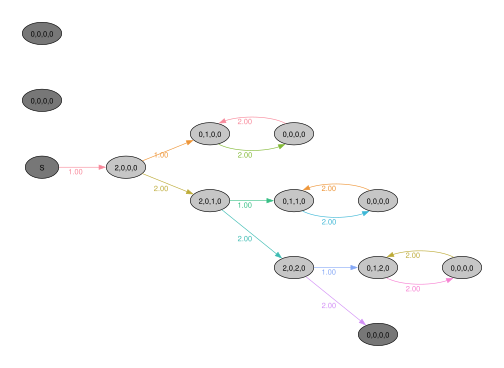

In [4]:
epoch_ipv, epoch_graph = joint_graph_epoch_ipv(_cont_joint_graph, t=100, return_graph=True)  
print('----')
print(epoch_ipv)
epoch_graph.plot()

In [5]:
# base graph
graph = Graph(coal_callback, ipv=ipv, indexer=indexer)
graph.update_weights([TRUE_THETA1])   

# discrete and continuous joint prob graphs
_disc_joint_graph = graph.joint_prob_graph(mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT, discrete=True) 
_cont_joint_graph = graph.joint_prob_graph(mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT, discrete=False) 

_disc_joint_graph.joint_prob_table()

,descendants_1,descendants_2,prob
t_vertex_index,,,
2,0,0,0.333333
4,1,0,0.222222
6,2,0,0.148148


In [6]:

# epoch_starts = [0, 1, 2]
# epoch_theta = [[1, 1], [1, 1], [1, 1]]
e = 3
epoch_starts = list(range(0, e*1, 1))
epoch_theta = [[1, 1]] * e
epoch_ipv = get_ipv(_cont_joint_graph)

## it seems the epoch_ipv converges to the values joint_prob_table gives on the discrete graph above, but passing that ipv to the final epoch produces wrong results 

In [7]:
for i in range(len(epoch_starts)-1):
    joint_graph_epoch = clone_with_ipv(_cont_joint_graph, epoch_ipv)
    joint_graph_epoch.update_weights(epoch_theta[i])
    epoch_ipv = joint_graph_epoch_ipv(_cont_joint_graph, t=epoch_starts[i+1])

epoch_ipv = clone_with_ipv(_disc_joint_graph, epoch_ipv)
jpt = epoch_ipv.joint_prob_table()
jpt

,descendants_1,descendants_2,prob
t_vertex_index,,,
2,0,0,0.454385
4,1,0,0.308593
6,2,0,0.212257


### maybe it is because the discrete joint graph cannot build a deficit when passed an ipv where all the prob is already at the t-states? Multiplying with the total joint prob (1-deficit) seems to do the trick if the ipv has already reached equilibrium:

In [ ]:
jpt.prob * _disc_joint_graph.joint_prob_table().prob.sum()

t_vertex_index
2    0.319752
4    0.217158
6    0.149366
Name: prob, dtype: float64

### ... before equilibrium is reached the total deficit over corrects. maybe because I should only correct with what the deficit has developed to at that time

### ... maybe the only way to do that i to use the continuous version with a very high end time like this:

In [ ]:
# base graph
graph = Graph(coal_callback, ipv=ipv, indexer=indexer)
graph.update_weights([TRUE_THETA1])   

# continuous joint prob graph
joint_graph = graph.joint_prob_graph(mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT, discrete=False) 

epoch_ipv = get_ipv(joint_graph)

for i in range(len(epoch_starts)-1):
    
    joint_graph_epoch = clone_with_ipv(joint_graph, epoch_ipv)
    joint_graph_epoch.update_weights(epoch_theta[i]) # TO NOT HAVE TO DO THE ELIMINATION FOR EACH EPOCH IT WOULD BE GREAT IF I
                                                     # COULD INCLUDE THE IPV IN THE UPDATE SOMEHOW...
                                                     # BUT THAT WOULD REQUIRE THAT THE IPV BECOMES PARAMETERIZED IN THE 
                                                     # TRACE SOMEHOW.

    epoch_ipv = joint_graph_epoch_ipv(joint_graph, t=epoch_starts[i+1])
    
joint_graph_epoch = clone_with_ipv(joint_graph, epoch_ipv)
joint_graph_epoch_ipv(joint_graph, t=9999)

array([0.00000000e+000, 1.26480805e-321, 3.33333333e-001, 1.26480805e-321,
       2.22222222e-001, 1.26480805e-321, 1.48148148e-001, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000])

In [ ]:
jpt.prob.sum()

np.float64(0.9999999999999998)

In [115]:
0.473684  * (0.333333333 + 0.222222222 + 0.1481)


0.33331037791462

In [102]:
joint_graph_epoch = clone_with_ipv(_cont_joint_graph, epoch_ipv)
joint_graph_epoch.update_weights(epoch_theta[0])
epoch_ipv = joint_graph_epoch_ipv(_cont_joint_graph, t=5) 

In [92]:
joint_graph_epoch_ipv(_cont_joint_graph, t=100)    


array([0.00000000e+000, 3.31458975e-131, 3.33333333e-001, 6.64865799e-129,
       2.22222222e-001, 6.66812859e-127, 1.48148148e-001, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000])

1.5000015833357083

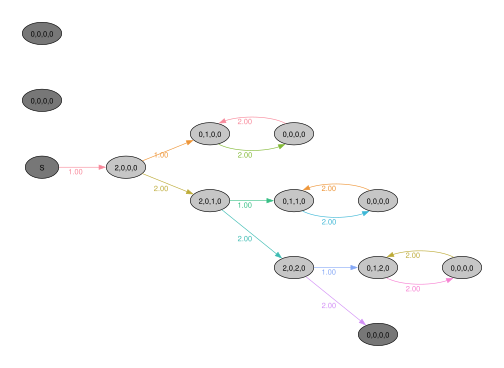

In [44]:
epoch_graph.plot()

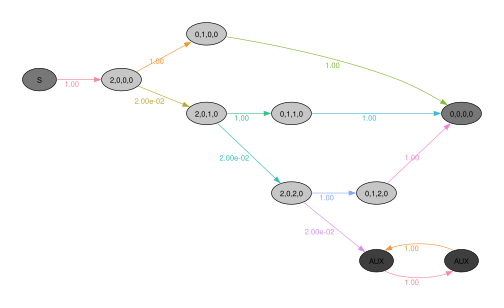

In [ ]:
joint_graph_epoch = clone_with_ipv(cont_joint_graph, epoch_ipv,)
cont_joint_graph.plot()

In [4]:
graph = Graph(coal_callback, ipv=ipv, indexer=indexer)
graph.update_weights([TRUE_THETA1])   

t_vertex_indices = []
for vertex in cont_joint_graph.vertices():
    for edge in vertex.edges():
        if len(edge.to().edges()) == 0:
            t_vertex_indices.append(vertex.index())
            break
t_vertex_indices = np.unique(t_vertex_indices)
t_vertex_indices

print('t-vertex indices:\n', t_vertex_indices)
print('t-states:\n', cont_joint_graph.states()[t_vertex_indices])

t-vertex indices:
 [2 4 6]
t-states:
 [[0 1 0 0]
 [0 1 1 0]
 [0 1 2 0]]


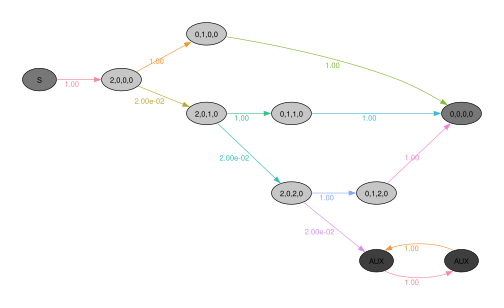

In [5]:
cont_joint_graph.plot()

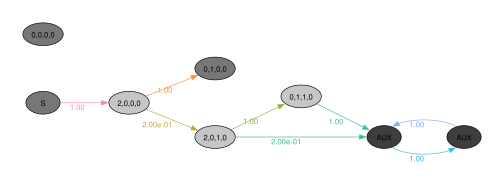

In [93]:
jg_one = clone_only_absorbing(cont_joint_graph, [t_vertex_indices[0]], t_vertex_indices, trash_index=5)
jg_one.plot()

In [94]:
ts = np.linspace(0.01, EPOCH_BOUNDARY, 200)                                                     
cdf = hit_time_cdfs(                                                                            
    cont_joint_graph,                                                                           
    t_vertex_indices,  
    5, # FIXME: hardcoded trash index
    ts,                                                                                         
    theta=[TRUE_THETA1, 1],
)                                                                                               

# Asymptote sanity check (large enough ts):                                                     
joint_graph.update_weights([TRUE_THETA1, 1])
jpt = joint_graph.joint_prob_table()                                                            
print("asymptote:", cdf[-1])
print("expected :", [jpt.loc[v, 'prob'] for v in t_vertex_indices]) 

asymptote: [0.83332825 0.13887786]
expected : [np.float64(0.8333333333333334), np.float64(0.13888888888888892)]


In [ ]:
from phasic import Graph, StateIndexer, Property, with_ipv
import numpy as np                                                                         
from vscodenb import set_vscode_theme
set_vscode_theme()
from itertools import combinations_with_replacement

def clone_only_absorbing(graph, absorb_indices, t_vertex_indices, trash_index):                                                   
    """         
    Deep-clone `graph`, dropping outgoing edges from each vertex in `absorb_indices`.
    All other vertices retain their original edges. Vertex indices are preserved.               
                                                                                                
    Use create_vertex (not find_or_create_vertex) so duplicate-state vertices                   
    in graph (e.g. the trash and universal-absorber vertices, which both have                      
    all-zero state) become distinct vertices in the clone.                                      
    """                                                                                         
    new = Graph(graph.state_length())                                                              
    if graph.parameterized():                                                                      
        new.set_param_length(graph.param_length())
                                                                                                
    start_old = graph.starting_vertex()
    vmap = {start_old.index(): new.starting_vertex()}                                           
                
    for v in graph.vertices():
        if v.index() == start_old.index():
            continue                                                                            
        vmap[v.index()] = new.create_vertex(list(v.state()))
                                                                                                
    skip = set(int(i) for i in absorb_indices)

    for v in graph.vertices():                                                                     
        if v.index() in skip:
            continue                                                                            
        if not v.edges():
            continue
        nv = vmap[v.index()]
        if graph.parameterized():
            for e in v.parameterized_edges():
                if v.index() in t_vertex_indices:                     
                    to_vertex = vmap[trash_index]
                else:
                    to_vertex = vmap[e.to().index()]
                nv.add_edge(to_vertex, list(e.edge_state(graph.param_length())))
        else:
            for e in v.edges():                                                                 
                if v.index() in t_vertex_indices:                     
                    to_vertex = vmap[trash_index]
                else:
                    to_vertex = vmap[e.to().index()]
                nv.add_edge(to_vertex, e.weight())
                                                                                                
    new.is_discrete = graph.is_discrete
    new._cache_trace = graph._cache_trace
    new._trace = None                                                                           
    new._trace_dirty = True
    new._last_theta = None                                                                      
    return new  

                                                                                                
def hit_time_cdfs(cont_joint_graph, t_vertex_indices, trash_index, t_grid, theta,
                granularity=0):                                                               
    """         
    Unconditional hit-time CDFs P(reach v by time t) for every v in
    `t_vertex_indices`, evaluated on `t_grid`.                                                  
                                                                                                
    Builds one clone per target where only that target is absorbing                             
    (its outgoing edges are dropped); all other t-vertices keep their                           
    structural edges so probability mass that would absorb elsewhere
    still leaves the sub-distribution rather than being misrouted to                            
    `target`.                                                                                   
                                                                                                
    Parameters                                                                                  
    ----------                                                                                  
    cont_joint_graph : Graph
        Continuous joint-prob graph (un-normalized weights, i.e. NOT
        was_dph). The original `joint_prob_graph(...)` instance is what                         
        you want here, *before* any was_dph normalization is applied.                           
    t_vertex_indices : iterable of int                                                          
        Indices of the t-vertices whose hit-time CDFs you want.                                 
    t_grid : 1D array of float                                                                  
        Time points at which to evaluate each CDF. Must be > 0.                                 
    theta : array-like
        Parameter vector to pass to update_weights.                                             
    granularity : int
        Granularity for the underlying uniformization (0 = auto).                               
                                                                                                
    Returns
    -------                                                                                     
    cdf : np.ndarray, shape (len(t_grid), len(t_vertex_indices))
        cdf[k, j] = P(reach t_vertex_indices[j] by time t_grid[k]).                             
        Asymptotes to P(reach v) = jpt.loc[v, 'prob'], not 1.                                   
        Divide column-wise by cdf[-1] for the conditional CDF.                                  
    """                                                                                         
    theta_list = np.asarray(theta).tolist()                                                     
    t_grid = np.asarray(t_grid, dtype=float)                                                    
    targets = [int(v) for v in t_vertex_indices]                                                
    out = np.empty((len(t_grid), len(targets)), dtype=float)                                    
                                                                                                
    for k, target in enumerate(targets):                                                        
        jg_one = clone_only_absorbing(cont_joint_graph, [target], t_vertex_indices, trash_index)
        jg_one.update_weights(theta_list)                                                       
        out[:, k] = np.asarray(
            [jg_one.cdf(float(t), granularity=granularity) for t in t_grid]                     
        )                                                                                       

    return out                                                                                  

In [95]:
import numpy as np                                                                              

# --- 1. Compute the unconditional CDFs ---------------------------------------                 
ts = np.linspace(0.01, EPOCH_BOUNDARY, 200)
cdf = hit_time_cdfs(                                                                            
    cont_joint_graph,
    t_vertex_indices,                                                                           
    5, # FIXME: hardcoded trash index
    ts,         
    theta=[TRUE_THETA1, 1],                                                                     
    granularity=100,         # bump if the asymptote check is loose
)                                                                                               


In [96]:
                
# --- 2. Asymptote sanity check ------------------------------------------------                
# As ts[-1] -> infty, cdf[-1, k] should approach P(reach t_vertex_indices[k]),
# which is exactly jpt.loc[v, 'prob'] from the (DPH) joint-prob table.                          
joint_graph.update_weights([TRUE_THETA1, 1])                                                    
jpt = joint_graph.joint_prob_table()                                                            
                                                                                                
asymptote = cdf[-1]                                         # shape (n_t,)                      
expected  = np.array([jpt.loc[v, 'prob'] for v in t_vertex_indices])
                                                                                                
abs_err = np.abs(asymptote - expected)
rel_err = abs_err / np.maximum(expected, 1e-12)                                                 
                                                                                                
print(f"{'t_vertex':>10}  {'asymptote':>12}  {'expected':>12}  "                                
    f"{'abs_err':>10}  {'rel_err':>10}")                                                      
for v, a, e, ae, re in zip(t_vertex_indices, asymptote, expected, abs_err, rel_err):            
    print(f"{v:>10}  {a:>12.6f}  {e:>12.6f}  {ae:>10.2e}  {re:>10.2e}")
                                                                                                
print(f"\nmax abs error: {abs_err.max():.2e}")                                                  
print(f"max rel error: {rel_err.max():.2e}")                                                    


  t_vertex     asymptote      expected     abs_err     rel_err
         2      0.833329      0.833333    4.76e-06    5.71e-06
         4      0.138878      0.138889    1.04e-05    7.51e-05

max abs error: 1.04e-05
max rel error: 7.51e-05


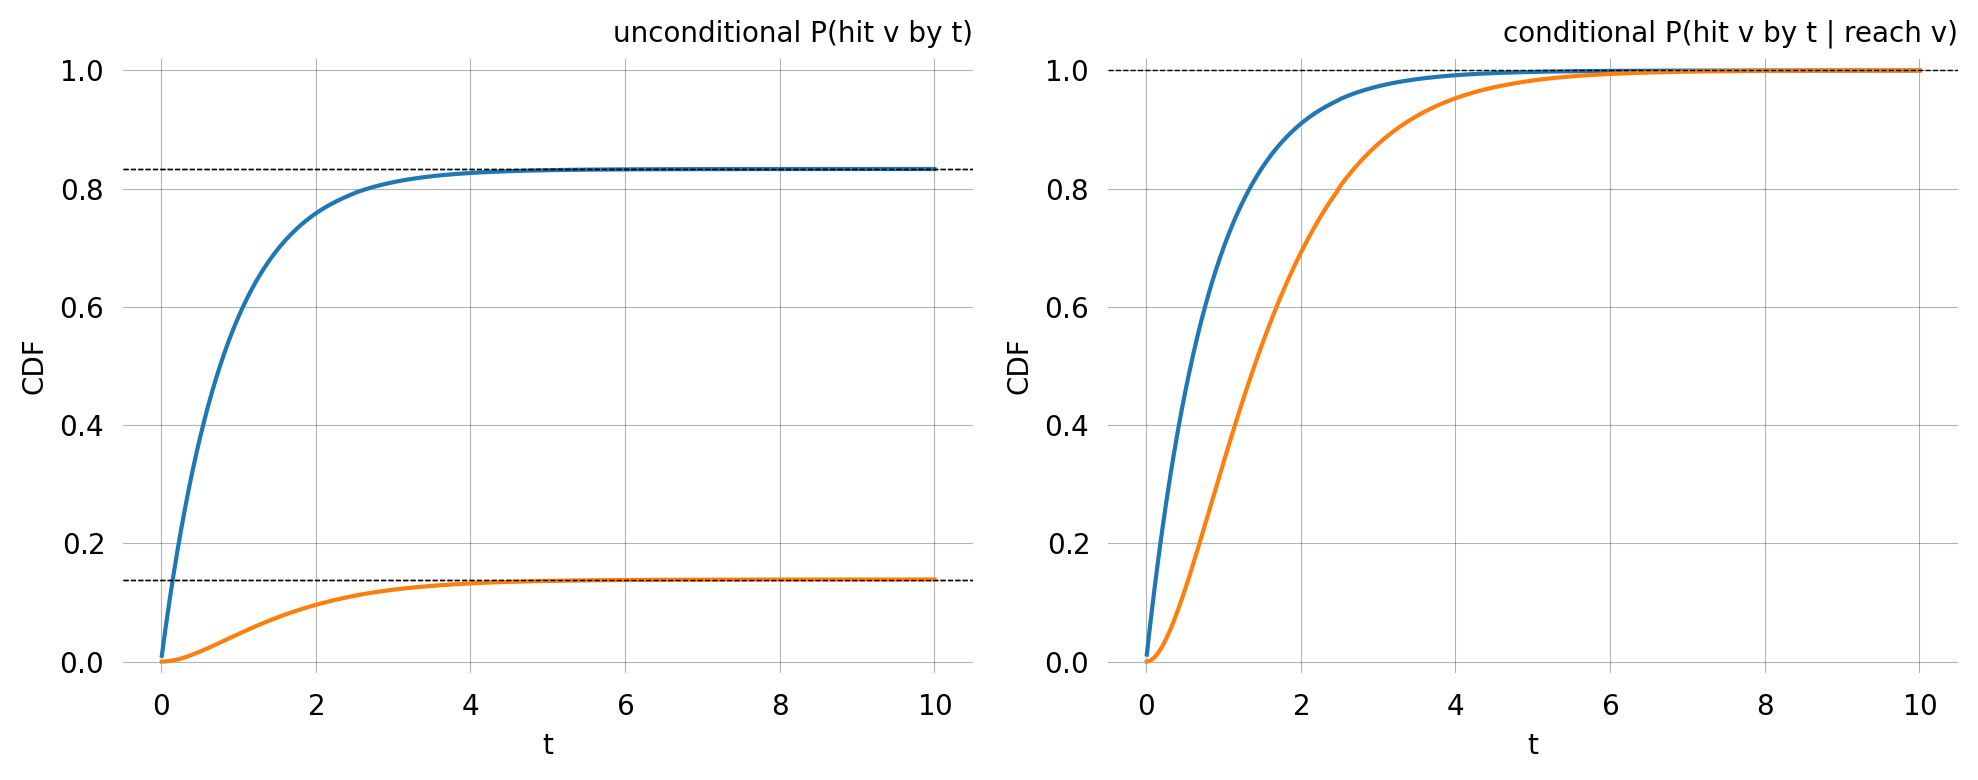

In [97]:
                                                                                                
# Heuristic pass/fail
if abs_err.max() > 1e-3:                                                                        
    print("WARNING: asymptote does not match. Try larger ts[-1] or granularity.")               
                                                                                                
# --- 3. Conditional hit-time CDF: P(hit by t | reach v) -----------------------                
# Each column is divided by its own asymptote, so each column ends at 1.0.                      
# Guard against divide-by-zero for unreachable t-vertices (asymptote == 0).                     
denom = np.where(asymptote > 0, asymptote, 1.0)                                                 
cdf_cond = cdf / denom[None, :]                                                                 
cdf_cond[:, asymptote <= 0] = np.nan       # mark unreachable targets explicitly                
                                                                                                
#You can quick-plot to eyeball the shapes:                                                       
                                                                                                
import matplotlib.pyplot as plt                                                                 
                
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)                              
for j, v in enumerate(t_vertex_indices):
    ax1.plot(ts, cdf[:, j],      label=f"v={v}")
    [ax1.axhline(a, color='k', lw=0.5, ls='--') for a in asymptote]
    ax2.plot(ts, cdf_cond[:, j], label=f"v={v}")
ax1.set_title("unconditional P(hit v by t)")                                                    
ax2.set_title("conditional P(hit v by t | reach v)")                                            
for ax in (ax1, ax2):                                                                           
    ax.set_xlabel("t"); ax.set_ylabel("CDF"); ax.set_ylim(-0.02, 1.02)                          
ax2.axhline(1.0, color='k', lw=0.5, ls='--')                                                    
plt.tight_layout(); plt.show()                                                                  
                                                                                                
# What "good" looks like:                                                                         
# - Each cdf[:, j] is monotone non-decreasing, asymptotes to expected[j].                         
# - cdf.sum(axis=1) should approach 1 as ts[-1] → ∞ (total mass conservation across t-vertices,   
# modulo any "trash" leak).                                                                    
# - Each cdf_cond[:, j] is monotone non-decreasing and asymptotes to 1.                           
                                                                    
# If a column is flat at zero, that target is unreachable under your theta (its expected[j] == 0);
# the np.where guard handles it without raising.  

In [34]:
# hack for now to get absorbing vertex index
absorbing_vertex_index = cont_joint_graph.vertices_length() - 1
assert not cont_joint_graph.vertex_at(absorbing_vertex_index).edges_length()

In [112]:
t_vertex_indices = []
for vertex in cont_joint_graph.vertices():
    for edge in vertex.edges():
        if len(edge.to().edges()) == 0:
            t_vertex_indices.append(vertex.index())
            break
t_vertex_indices = np.unique(t_vertex_indices)
t_vertex_indices

array([2, 4])

In [117]:
#  I get only zeros. stop_probability apparently also does not work for absorbing states, which also makes sense when you  
#   think about it                                                                                                          

# ⏺ You're right — and the underlying reason is that on the joint graph, update_weights row-normalizes because of the
#   was_dph flag, so on a DTMC the "stop probability at time t" is computed per discrete-step, and an absorbing state with
#   no outgoing edges has no defined step — the C code likely just leaves its mass at zero (or treats it as unreachable from
#    itself). Let me verify:

#   Searched for 3 patterns (ctrl+o to expand)

# ⏺ The implementation is on the C++ side and not directly visible here, but the empirical result is clear: stop_probability
#    doesn't accumulate mass at terminal vertices — it returns the survival distribution over transient states, exactly as
#   the name suggests. Mass that has been absorbed is gone from its perspective.

#   So the right approach is the one I gave you first: per-target reward transform + cdf(). That's the route that actually
#   works on the existing API. Two things make it more efficient than I initially worried about:

#   1. The reward transform on the joint graph is cheap relative to building it.
#   2. You can batch all t values in one cdf call (it accepts an array).

#   Here's a clean version that gets all t-vertex CDFs at once, on a single grid:

def hit_time_cdfs(jg_cont, t_vertex_indices, t_grid, theta, granularity=0):                                                                     
    """                                                                                                                                         
    Unconditional hit-time CDF P(reach v by time t) for every v in                                                                              
    `t_vertex_indices`, evaluated on `t_grid`.                                                                                                  
                                                                                                                                                
    Returns                                                                                                                                     
    -------                                                                                                                                     
    cdf : np.ndarray, shape (len(t_grid), len(t_vertex_indices))
        Asymptotes to P(reach v) = jpt.loc[v, 'prob'], not 1.                                                                                   
    """                                                                                                                                         
    theta_list = np.asarray(theta).tolist()
    n_v = jg_cont.vertices_length()                                                                                                             
    out = np.empty((len(t_grid), len(t_vertex_indices)), dtype=float)                                                                           
    t_set = set(int(v) for v in t_vertex_indices)                                                                                               
                                                                                                                                                
    for k, target in enumerate(t_vertex_indices):                                                                                               
        rewards = np.ones(n_v)
        # Block paths that absorb at any *other* t-vertex.                                                                                      
        for v in t_set:                                                                                                                         
            if v != target:                                                                                                                     
                rewards[v] = 0.0                                                                                                                
        g_hit = jg_cont.reward_transform(rewards)
        print(rewards)
        print(g_hit.states())
        g_hit.update_weights(theta_list)                                                                                                        
        out[:, k] = np.asarray(g_hit.cdf(np.asarray(t_grid), granularity=granularity))                                                          
                                                                                                                                                
    return out                                                                                                                                  
                                                                                                                                                
# Two notes:      

# - Pass the time grid as an array. g_hit.cdf(t_array) is vectorized internally (the same uniformization sweep gets reused across t values), so   
# it's much cheaper than a Python loop over t.
# - About reward_transform on a t-vertex. Earlier you said you can't reward-transform an absorbing vertex. That refers to giving a non-zero reward
# to the single final absorbing state — there's no path that leaves it, so the reward is meaningless there. But here the t-vertices are not the  
# final absorber: in the joint graph they each have a structural rate-1 edge onward to the universal absorber. So they're transient from the C
# engine's point of view, and assigning rewards to them is well-defined. (Setting rewards[other_t] = 0 makes paths through those vertices         
# contribute zero hit-time, effectively rerouting the hit-time mass to only count paths that go through target.)

# If reward_transform does throw on a t-vertex in your specific build (worth a quick test), the fallback is to set the reward on other_t to a tiny
# positive number — 1e-12 — instead of 0. That's still a valid reward and the bias is negligible.
                                                                                                                                                
# Quick correctness check you can run:

cdf = hit_time_cdfs(cont_joint_graph, t_vertex_indices, ts, [TRUE_THETA1, 1])
# Asymptote should match jpt['prob'] for each target                                                                                            
joint_graph.update_weights([TRUE_THETA1, 1])                                                                                                        
jpt = joint_graph.joint_prob_table()                                                                                                                
print("asymptote (large t):", cdf[-1])                                                                                                          
print("expected (jpt prob):", [jpt.loc[v, 'prob'] for v in t_vertex_indices])                                                                   
                                                                                                                                                
# The two arrays should agree once ts[-1] is large enough.                                                                                        
                                                                                                                                                
# For the conditional CDF (given v is reached), divide each column by its asymptote:                                                              
                
cdf_cond = cdf / cdf[-1][None, :]   # asymptotes to 1   

[1. 1. 1. 1. 0. 1. 1. 1.]
[[0 0 0 0]
 [2 0 0 0]
 [0 1 0 0]
 [2 0 1 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


RuntimeError: Cannot call update_weights() on empty graph (no edges added yet). Add edges using add_edge() before calling update_weights().

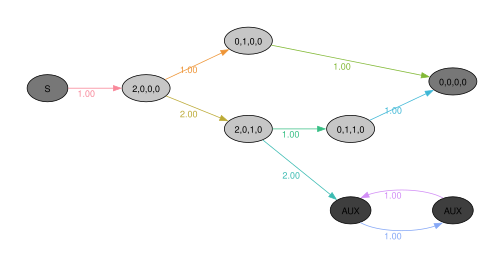

In [ ]:
# fixme: maybe just derive this from the discrete version using clone or something if that is faster...
cont_joint_graph = graph.joint_prob_graph(mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT, discrete=False) 
cont_joint_graph.plot()

In [81]:
# hack for now to get absorbing vertex index
absorbing_vertex_index = cont_joint_graph.vertices_length() - 1
assert not cont_joint_graph.vertex_at(absorbing_vertex_index).edges_length()

In [93]:
t_vertex_indices = []
for vertex in cont_joint_graph.vertices():
    for edge in vertex.edges():
        if len(edge.to().edges()) == 0:
            t_vertex_indices.append(vertex.index())
            break
t_vertex_indices = np.unique(t_vertex_indices)
t_vertex_indices

array([2, 4])

[[0 1 0 0]
 [0 1 1 0]]


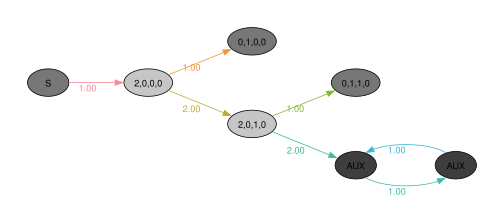

In [96]:
def clone_without_absorbing(jg):                                                                                                                
    new = Graph(jg.state_length())
    if jg.parameterized():                                                                                                                      
        new.set_param_length(jg.param_length())
                                                                                                                                                
    start_old = jg.starting_vertex()
    vmap = {start_old.index(): new.starting_vertex()}                                                                                           
                                                                                                                                                
    # Use create_vertex (not find_or_create) so duplicate-state vertices                                                                        
    # in jg (e.g. the trash and absorbing vertices, which both have all-zero                                                                    
    # states) become distinct vertices in `new`. find_or_create_vertex would                                                                    
    # collapse them and corrupt the index mapping.                                                                                              
    for v in jg.vertices():                                                                                                                     
        if v.index() == start_old.index():                                                                                                      
            continue
        if not v.edges():                                                                                                                       
            continue

        vmap[v.index()] = new.create_vertex(list(v.state()))                                                                                    
                
    # Copy edges, dropping outgoing edges of absorbing-in-source vertices.                                                                      
    for v in jg.vertices():
        if v.index() not in vmap:
            continue
        nv = vmap[v.index()]
        if jg.parameterized():                                                                                                                  
            for e in v.parameterized_edges():
                if e.to().index() not in vmap:
                    continue
                nv.add_edge(vmap[e.to().index()],                                                                                               
                            list(e.edge_state(jg.param_length())))
        else:                                                                                                                                   
            for e in v.edges():
                if e.to().index() not in vmap:
                    continue                
                nv.add_edge(vmap[e.to().index()], e.weight())                                                                                   
                                                                                                                                                
    new.is_discrete = jg.is_discrete
    new._cache_trace = jg._cache_trace                                                                                                          
    new._trace = None                                                                                                                           
    new._trace_dirty = True
    new._last_theta = None                                                                                                                      
    return new                                                                                                                                
                

jg_hit = clone_without_absorbing(cont_joint_graph)                                                                  
jg_hit.update_weights([TRUE_THETA1, 1])
print(jg_hit.states()[t_vertex_indices])
jg_hit.plot()

In [101]:
np.array(jg_hit.stop_probability(0.5))[t_vertex_indices]

array([0., 0.])

In [97]:
                                                                                           
# ts = np.linspace(0.01, EPOCH_BOUNDARY, 200)
ts = np.linspace(0.01, 0.5, 200)
cdf = np.array([np.array(jg_hit.stop_probability(t))[t_vertex_indices] for t in ts]) 
cdf

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.

In [86]:
jg_hit.states()[t_vertex_indices]

array([[2, 0, 0, 0],
       [2, 0, 1, 0]], dtype=int32)

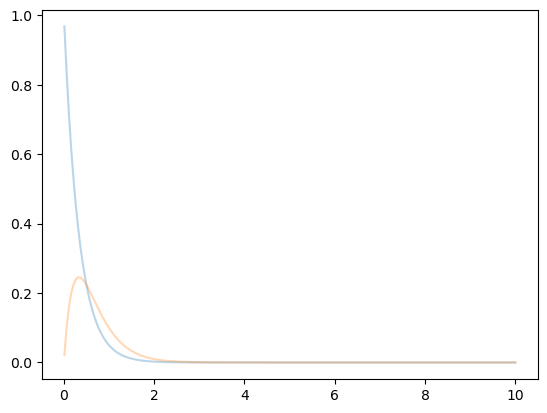

In [87]:

import matplotlib.pyplot as plt
plt.plot(ts, cdf, alpha=0.3)

In [43]:

a = jg_hit.stop_probability(EPOCH_BOUNDARY)
type(a)

list

In [ ]:
# Build a hit-time variant by zeroing the t->absorber edges 
rewards = np.ones(cont_joint_graph.vertices_length())
rewards[cont_joint_graph.starting_vertex().index()] = 0.0
rewards[absorbing_vertex_index] = 0.0
rewards

array([0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.])

In [ ]:

g_hit_all = cont_joint_graph.reward_transform(rewards)
g_hit_all.plot()

In [ ]:
g_hit_all.update_weights([TRUE_THETA1, 1])
g_hit_all.plot()

In [ ]:

ts = np.linspace(0.01, EPOCH_BOUNDARY, 200)
cdf = np.array([g_hit_all.stop_probability(t)[t_vertex_indices] for t in ts])
cdf

In [6]:
# i cannot just use stop probability because the t-states are only transient and their exit rates of 1 are meaningless in the continuous graph
#cont_joint_graph.stop_probability(EPOCH_BOUNDARY)
cont_joint_graph.stop_probability(100)


# I need to reward transform after making the t-vertices absorbing

[0.0,
 1.6356820295068045e-132,
 7.141852596287604e-45,
 4.9216090528073305e-132,
 2.2606529178203378e-42,
 7.220036854167213e-45,
 7.113442039297322e-45,
 8.080105109944279e-43,
 7.190891845156977e-45,
 7.746543569453099e-43,
 4.3178784171201496e-43,
 0.00019504197102752915,
 0.00019504197102752222,
 0.0]

In [7]:
cont_joint_graph.states()

array([[0, 0, 0, 0, 0, 0],
       [3, 0, 0, 0, 0, 0],
       [1, 1, 0, 0, 0, 0],
       [3, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [1, 1, 0, 1, 0, 0],
       [1, 1, 0, 0, 1, 0],
       [0, 0, 1, 1, 0, 0],
       [1, 1, 0, 1, 1, 0],
       [0, 0, 1, 0, 1, 0],
       [0, 0, 1, 1, 1, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]], dtype=int32)

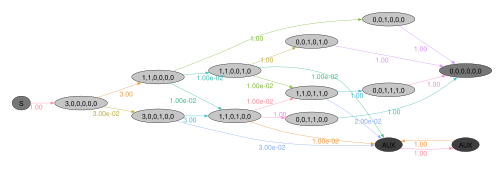

In [3]:
cont_joint_graph.update_weights([TRUE_THETA1, 1])                                              

cont_joint_graph.plot(nodesep=0.5, fontsize=20)

In [ ]:
import numpy as np                                                                         
from phasic import Graph, StateIndexer, Property, with_ipv

from itertools import combinations_with_replacement

N_SAMPLES = 5
EPOCH_BOUNDARY = 0.5
TRUE_THETA1 = 2.0
TRUE_THETA2 = 0.5
MUTATION_RATE = 0.01
REWARD_LIMIT = 5      # cap on mutations per locus the joint graph tracks

# Indexer over the lineage state — one Property: descendants count per block.
indexer = StateIndexer(
    lineages=[Property('descendants', min_value=1, max_value=N_SAMPLES)],
)
ipv = [0] * indexer.state_length
ipv[indexer.lineages.props_to_index(descendants=1)] = N_SAMPLES  # start with N_SAMPLES singletons


@with_ipv(ipv)
def coal_callback(state, indexer=None):
    transitions = []
    for i, j in combinations_with_replacement(range(indexer.lineages.state_length), 2):
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        new[min(i + j + 1, state.size - 1)] += 1
        pair_count = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, [pair_count]])
    return transitions


def sample_path_with_continuous_time(jg, theta_proposal, target_vertex, n=1, rng=None):      
    """
    Sample paths through a (discrete-time) joint_prob_graph conditioned on                   
    ending at `target_vertex`, and map each step's discrete entry time back                  
    to continuous time by resampling sojourns from Exp(R_v_raw), where                       
    R_v_raw is the un-normalized exit rate from raw edge coefficients.                       
                                                                                            
    Parameters                                                                               
    ----------                                                                               
    jg : Graph                                                                             
        A joint_prob_graph (is_discrete=True, was_dph=True). Its edge
        coefficients must already encode the proposal CTMC.                                  
    theta_proposal : array-like, shape (n_params,)                                           
        Proposal parameter vector. Used both to set the graph weights for                    
        h-guided sampling AND to compute raw exit rates R_v_raw.                             
    target_vertex : int                                                                      
        Index of the t-vertex (terminal observation) to condition on.                        
    n : int                                                                                  
        Number of paths to sample.                                                         
    rng : np.random.Generator, optional                                                      
                                                                                            
    Returns                                                                                  
    -------                                                                                
    list of list of (state_tuple, entry_time_float)
        One list per path. Each element is (vertex_state, continuous entry time).            
        First element has entry_time=0.0 (starting vertex).                                  
        Last element is the absorbing target vertex.                                         
    """                                                                                      
    rng = rng or np.random.default_rng()                                                     
    theta_proposal = np.asarray(theta_proposal, dtype=float)                                 
                                                                                            
    # 1. Set weights so the C sampler's h-guidance reflects the proposal CTMC.               
    jg.update_weights(theta_proposal.tolist())                                               
                                                                                            
    # 2. Precompute raw (un-normalized) exit rate R_v_raw for every vertex,                  
    #    using the original edge coefficients (these are NOT touched by                      
    #    update_weights's row-normalization on a was_dph graph).                             
    n_params = jg.param_length()                                                             
    vertices = jg.vertices()                                                                 
    R_raw = np.zeros(jg.vertices_length(), dtype=float)                                      
    for v in vertices:                                                                       
        if v.edges_length() == 0:                                                            
            continue                                                                         
        edges = v.parameterized_edges()                                                    
        if not edges:                                                                        
            continue                                                                         
        coeffs = np.array([list(e.edge_state(n_params)) for e in edges])
        if coeffs.ndim == 1:                                                                 
            coeffs = coeffs.reshape(1, -1)                                                 
        if coeffs.shape[1] < n_params:                                                       
            coeffs = np.pad(coeffs, ((0, 0), (0, n_params - coeffs.shape[1])))             
        edge_rates = coeffs @ theta_proposal      # shape (n_edges,)                         
        R_raw[v.index()] = edge_rates.sum()                                                  
                                                                                            
    # 3. Sample n paths. The C sampler returns Exp(1) sojourns on a was_dph                  
    #    graph, so we ignore its entry_times and resample from Exp(R_v_raw).               
    paths = jg.sample_path_conditioned([int(target_vertex)], n=n)                            
    if n == 1:                                                                               
        paths = [paths]                                                                      
                                                                                            
    out = []                                                                                 
    for path in paths:                                                                     
        indices = np.asarray(path['vertex_indices'], dtype=int)
        states = [tuple(int(x) for x in vertices[int(vi)].state()) for vi in indices]        
        n_steps = len(indices)                                                               
                                                                                            
        cont_times = np.zeros(n_steps, dtype=float)                                          
        # cont_times[0] = 0.0 (start). For step k we draw a sojourn at vertex              
        # indices[k] and add it to cont_times[k] to get cont_times[k+1].                     
        for k in range(n_steps - 1):                                                         
            v_idx = int(indices[k])                                                          
            r = R_raw[v_idx]                                                                 
            if r > 0.0:                                                                      
                cont_times[k + 1] = cont_times[k] + rng.exponential(1.0 / r)
            else:                                                                            
                # Absorbing or unreachable; no further continuous time accrues.            
                cont_times[k + 1] = cont_times[k]                                            
        out.append(list(zip(states, cont_times.tolist())))                                 
                                                                                            
    return out                                                                             

graph = Graph(coal_callback, indexer=indexer)

# Usage:                                                                                     

# Build joint-prob graph (already discrete + was_dph).
jg = graph.joint_prob_graph(indexer, mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT)                       


jg.update_weights([TRUE_THETA1, MUTATION_RATE])                                              
                                                                                            
# 2. The joint probability table has one row per terminal (t-)vertex.                        
#    Its index is the vertex index; the leading columns are the feature counts.
jpt = jg.joint_prob_table()                                                                  
# Example layout:                                                                            
#                 feat0  feat1  feat2     prob                                               
# vertex_idx                                                                                 
#       12          0      1      0     0.213
#       17          1      0      0     0.456                                                
#       ...     
                                                                                            
# 3. Map a feature-count tuple -> vertex index.                                              
obs2idx = jpt.groupby(jpt.columns[:-1].to_list()).groups
# obs2idx[(0, 1, 0)] -> Index([12])                                                          

obs2idx

{(0, 0, 0, 0, 0): [20], (0, 0, 0, 1, 0): [49], (0, 0, 0, 2, 0): [90], (0, 0, 0, 3, 0): [148], (0, 0, 1, 0, 0): [44], (0, 0, 1, 1, 0): [116], (0, 0, 1, 2, 0): [186], (0, 0, 1, 3, 0): [271], (0, 0, 2, 0, 0): [83], (0, 0, 2, 1, 0): [188], (0, 0, 2, 2, 0): [272], (0, 0, 2, 3, 0): [363], (0, 0, 3, 0, 0): [141], (0, 0, 3, 1, 0): [274], (0, 0, 3, 2, 0): [364], (0, 0, 3, 3, 0): [451], (0, 1, 0, 0, 0): [41], (0, 1, 0, 1, 0): [106], (0, 1, 0, 2, 0): [172], (0, 1, 0, 3, 0): [254], (0, 1, 1, 0, 0): [81], (0, 1, 1, 1, 0): [204], (0, 1, 1, 2, 0): [295], (0, 1, 1, 3, 0): [393], (0, 1, 2, 0, 0): [139], (0, 1, 2, 1, 0): [297], (0, 1, 2, 2, 0): [394], (0, 1, 2, 3, 0): [487], (0, 1, 3, 0, 0): [217], (0, 1, 3, 1, 0): [396], (0, 1, 3, 2, 0): [488], (0, 1, 3, 3, 0): [566], (0, 2, 0, 0, 0): [78], (0, 2, 0, 1, 0): [174], (0, 2, 0, 2, 0): [255], (0, 2, 0, 3, 0): [346], (0, 2, 1, 0, 0): [137], (0, 2, 1, 1, 0): [300], (0, 2, 1, 2, 0): [398], (0, 2, 1, 3, 0): [490], (0, 2, 2, 0, 0): [215], (0, 2, 2, 1, 0): [400],

In [ ]:

obs = (0, 0, 2, 3, 0)

target_v = int(obs2idx[tuple(obs)][0])                                            

sample_path_with_continuous_time(                                                
        jg, theta_proposal=[TRUE_THETA1, MUTATION_RATE],                                                   
        target_vertex=target_v, n=200,                                                       
    )   

[[((0, 0, 0, 0, 0, 0, 0, 0, 0, 0), 0.0),
  ((5, 0, 0, 0, 0, 0, 0, 0, 0, 0), 0.16754985885582557),
  ((3, 1, 0, 0, 0, 0, 0, 0, 0, 0), 0.3803084146511154),
  ((2, 0, 1, 0, 0, 0, 0, 0, 0, 0), 0.38468904554375744),
  ((2, 0, 1, 0, 0, 0, 0, 1, 0, 0), 0.3974695077219354),
  ((2, 0, 1, 0, 0, 0, 0, 2, 0, 0), 0.8185981636673366),
  ((1, 0, 0, 1, 0, 0, 0, 2, 0, 0), 1.0094343265358368),
  ((1, 0, 0, 1, 0, 0, 0, 2, 1, 0), 1.0397046069544431),
  ((1, 0, 0, 1, 0, 0, 0, 2, 2, 0), 1.228789870194644),
  ((1, 0, 0, 1, 0, 0, 0, 2, 3, 0), 3.1084105598890854),
  ((0, 0, 0, 0, 1, 0, 0, 2, 3, 0), 3.2746427676590697)],
 [((0, 0, 0, 0, 0, 0, 0, 0, 0, 0), 0.0),
  ((5, 0, 0, 0, 0, 0, 0, 0, 0, 0), 0.04689156287487077),
  ((3, 1, 0, 0, 0, 0, 0, 0, 0, 0), 0.05095099100988705),
  ((2, 0, 1, 0, 0, 0, 0, 0, 0, 0), 0.09145277397585225),
  ((2, 0, 1, 0, 0, 0, 0, 1, 0, 0), 0.15402257276954137),
  ((2, 0, 1, 0, 0, 0, 0, 2, 0, 0), 0.19059604991633003),
  ((1, 0, 0, 1, 0, 0, 0, 2, 0, 0), 0.20170396797626233),
  ((1, 0, 0, 1

In [ ]:
#   For a list of observations:                                                                  
                
def observed_to_terminals(jg, observed_data, theta_proposal):                                
    jg.update_weights(np.asarray(theta_proposal).tolist())                                   
    jpt = jg.joint_prob_table()                                                              
    obs2idx = jpt.groupby(jpt.columns[:-1].to_list()).groups                                 
    targets = []                                                                             
    for obs in observed_data:
        idx = obs2idx[tuple(obs)]                                                            
        if len(idx) == 1:                                                                    
            targets.append(int(idx[0]))
        else:                                                                                
            # Tie: multiple terminal vertices match this observation.
            # Pick proportionally to their probability mass (same heuristic                  
            # as probability_matching).                                                      
            p = jpt.loc[idx, 'prob'].to_numpy()                                              
            p = p / p.sum()                                                                  
            targets.append(int(np.random.choice(idx, p=p)))
    return targets                                                                           



In [24]:
observed_data = [obs]

#So the full pipeline becomes:                                                                

n_path_samples = 5
jg = graph.joint_prob_graph(indexer, mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT)                       
targets = observed_to_terminals(jg, observed_data, [TRUE_THETA1, MUTATION_RATE])                           
                                                                                            
for obs, target_v in zip(observed_data, targets):                                            
    paths = sample_path_with_continuous_time(                                                
        jg, theta_proposal=[TRUE_THETA1, MUTATION_RATE],                                                   
        target_vertex=target_v, n=n_path_samples,                                                       
    )
    for path in paths:
        states, times = zip(*path)
        print(times)
        state_idx = np.searchsorted(times, EPOCH_BOUNDARY) - 1
        assert state_idx < len(times)
        assert times[state_idx] < EPOCH_BOUNDARY
        print(states[state_idx])
        vertex = graph.find_vertex((1, 0, 0, 1, 0, 0, 0, 2, 0, 0))
        print(vertex.index())
    # times = []
    # paths = [p for state, time in paths]
    # print(paths)                                                                                 
    # # paths[i] is [(state_tuple, continuous_time), ...]                                      
    


: 

In [ ]:

# Pick the t-vertex you want to condition on. For an SFS-style model this is                 
# the terminal vertex matching your observed locus.                                          
jpt = jg.joint_prob_table()                  # also sets weights internally                  
target_v = int(observed_terminal_vertex_idx) # one of jpt.index                              
                                                                                            
paths = sample_path_with_continuous_time(                                                    
    jg, theta_proposal=[TRUE_THETA1], target_vertex=target_v, n=200                                  
)                                                                                            
                                                                                            
for state, t in paths[0]:                                                                    
    print(t, state)


In [ ]:
                                                                                               
  Two things to watch:                                                                       

  1. update_weights must be called with the proposal theta before sampling, because the C-side 
  h-guidance uses the row-normalized weights derived from those coefficients. The snippet does
  this in step 1.                                                                              
  2. The continuous times are stochastic — a fresh resample per call. If you use these inside
  an importance-weight calculation, the same resample should be reused for both the            
  proposal-density and target-density terms (otherwise the ratio is biased). The snippet
  returns the resampled times, so just keep them around if you need them downstream.           
                                                                                             
  Want me to also add the matching importance-weight term (proposal vs. target CTMC density) so
   the same paths can drop into a BFFG-style estimator?

In [ ]:
# from phasic import Graph, StateIndexer, Property, with_ipv
# import numpy as np                                                                         
# from vscodenb import set_vscode_theme
# set_vscode_theme()
# from itertools import combinations_with_replacement

# N_SAMPLES = 2
# # EPOCH_BOUNDARY = 0.5
# EPOCH_BOUNDARY = 10
# TRUE_THETA1 = 1
# TRUE_THETA2 = 0.5
# MUTATION_RATE = 0.1
# # MUTATION_RATE = 1
# REWARD_LIMIT = 2      # cap on mutations per locus the joint graph tracks

# def coal_callback(state, indexer=None):
#     transitions = []
#     for i, j in combinations_with_replacement(range(indexer.lineages.state_length), 2):
#         same = int(i == j)
#         if same and state[i] < 2:
#             continue
#         if not same and (state[i] < 1 or state[j] < 1):
#             continue
#         new = state.copy()
#         new[i] -= 1
#         new[j] -= 1
#         new[min(i + j + 1, state.size - 1)] += 1
#         pair_count = state[i] * (state[j] - same) / (1 + same)
#         transitions.append([new, [pair_count]])
#     return transitions


# # graph = Graph(coal_callback, indexer=indexer)
# # graph.update_weights([TRUE_THETA1])                                              

# # joint_graph = graph.joint_prob_graph(mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT) 
# # cont_joint_graph = graph.joint_prob_graph(mutation_rate=MUTATION_RATE, reward_limit=REWARD_LIMIT, discrete=False) 
# # cont_joint_graph.plot()
# # #joint_graph.update_weights([TRUE_THETA1, 1])                                              